<a href="https://colab.research.google.com/github/NisalJayaweera/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Intensity_Transformation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering.

**230300C - Jayaweera N.S.**

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import rgb2gray
from skimage.io import imread


**1. Piecewise-Linear Intensity Transformation**

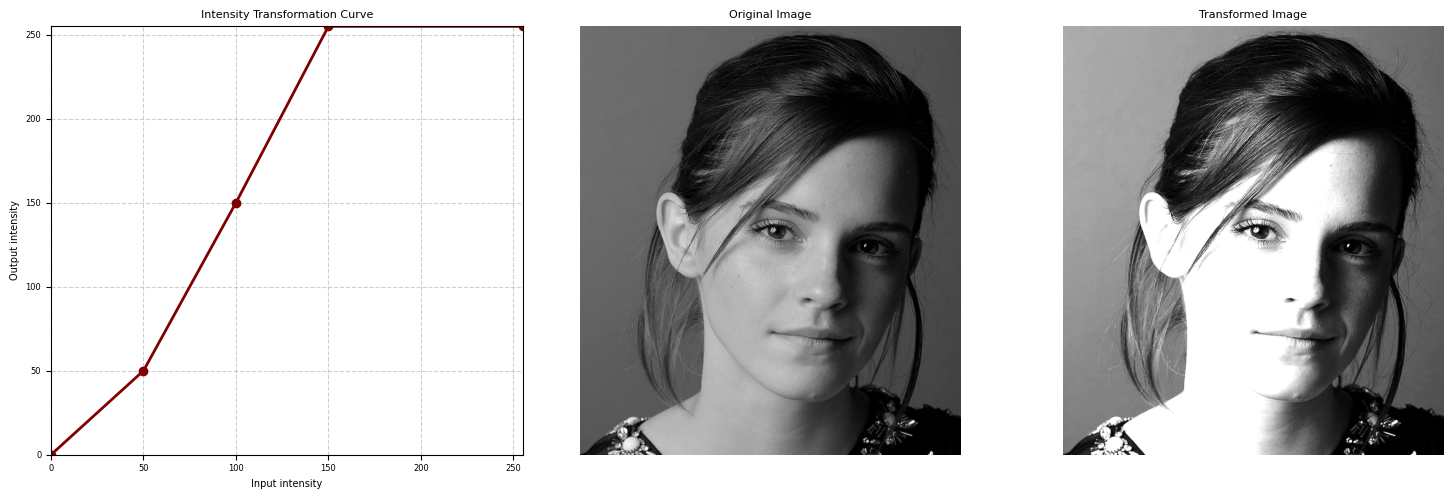

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import rgb2gray
from skimage.io import imread
import cv2 # Assuming cv2 is needed later or for show function

def intensity_transform(im, breakpoints):
    im_float = im.astype(float)
    out_img = np.zeros_like(im_float)

    # Sort breakpoints by input intensity (x-coordinate)
    breakpoints = breakpoints[np.argsort(breakpoints[:, 0])]

    # Create a lookup table (LUT) for the transformation
    lut = np.zeros(256, dtype=float)
    input_intensities = np.arange(256)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i+1]

        if x1 == x2:
            # If x-coordinates are the same, the output is y1 (or y2)
            mask_img = (im_float == x1)
            out_img[mask_img] = y1

            mask_lut = (input_intensities == x1)
            lut[mask_lut] = y1
            continue

        # Linear interpolation for the current segment
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1

        # Apply transformation to image pixels within this segment
        mask_img = (im_float >= x1) & (im_float <= x2)
        out_img[mask_img] = slope * im_float[mask_img] + intercept

        # Apply transformation to LUT entries within this segment
        mask_lut = (input_intensities >= x1) & (input_intensities <= x2)
        lut[mask_lut] = slope * input_intensities[mask_lut] + intercept

    # Handle values outside the defined breakpoints
    # Values below the first breakpoint
    out_img[im_float < breakpoints[0, 0]] = breakpoints[0, 1]
    lut[input_intensities < breakpoints[0, 0]] = breakpoints[0, 1]

    # Values above the last breakpoint
    out_img[im_float > breakpoints[-1, 0]] = breakpoints[-1, 1]
    lut[input_intensities > breakpoints[-1, 0]] = breakpoints[-1, 1]

    # Clip and convert to uint8 for both image and LUT
    out_img = np.clip(out_img, 0, 255).astype(np.uint8)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return out_img, lut

image_path = '/images/q1.jpeg'

try:
    original_im = rgb2gray(imread(image_path))
    original_im = img_as_ubyte(original_im)
except FileNotFoundError:
    print(f"Warning: Image '{image_path}' not found. Using a synthetic gradient image instead.")
    original_im = np.tile(np.linspace(0, 255, 256, dtype=np.uint8), (256, 1))

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
])

transformed_im, _ = intensity_transform(original_im, breakpoints) # Unpack, but ignore LUT for this plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

xp = breakpoints[:, 0]
fp = breakpoints[:, 1]
axes[0].plot(xp, fp, color='maroon', linewidth=2, marker='o')
axes[0].set_title('Intensity Transformation Curve')
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].imshow(original_im, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**2. Accentuating White Matter and Gray Matter in a Brain PD Image**

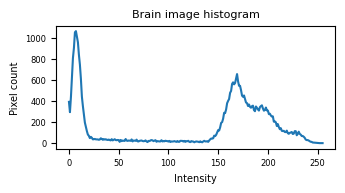

In [23]:
brain = cv2.imread(f"/images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([brain], [0], None, [256], [0,256]).flatten()
plt.figure(figsize=(3.6,1.6))
plt.plot(hist)
plt.title("Brain image histogram")
plt.xlabel("Intensity"); plt.ylabel("Pixel count")
plt.show()

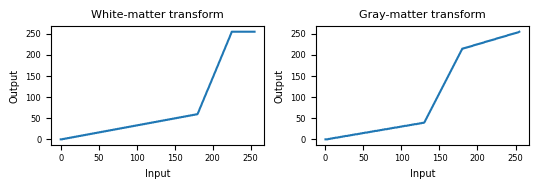

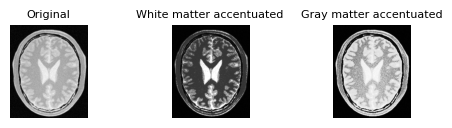

In [22]:
wm_breakpoints_list = np.array([(0,0), (180,60), (225,255), (255,255)])
gm_breakpoints_list = np.array([(0,0), (130,40), (180,215), (255,255)])

wm_breakpoints = np.array(wm_breakpoints_list)
gm_breakpoints = np.array(gm_breakpoints_list)

wm_img, wm_lut = intensity_transform(brain, wm_breakpoints)
gm_img, gm_lut = intensity_transform(brain, gm_breakpoints)

fig, ax = plt.subplots(1,2, figsize=(5.4,1.9))
ax[0].plot(wm_lut); ax[0].set_title("White-matter transform"); ax[0].set_xlabel("Input"); ax[0].set_ylabel("Output")
ax[1].plot(gm_lut); ax[1].set_title("Gray-matter transform"); ax[1].set_xlabel("Input"); ax[1].set_ylabel("Output")
plt.tight_layout(); plt.show()

show([brain, wm_img, gm_img],
     ["Original", "White matter accentuated", "Gray matter accentuated"], figsize=(5.33,1.3))

**3. Gamma Correction on the L Plane**

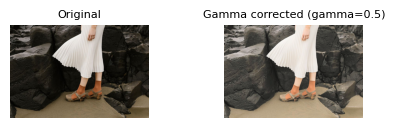

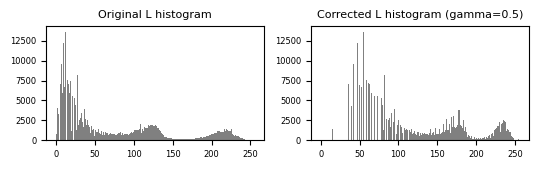

In [25]:
bgr3 = cv2.imread(f"/images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")
lab3 = cv2.cvtColor(bgr3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab3)
gamma = 0.5
L_norm = L.astype(np.float64) / 255.0
L_gamma = np.clip(np.power(L_norm, gamma) * 255.0, 0, 255).astype(np.uint8)
lab3_out = cv2.merge([L_gamma, a, b])
bgr3_out = cv2.cvtColor(lab3_out, cv2.COLOR_LAB2BGR)
show([bgr3, bgr3_out], ["Original", f"Gamma corrected (gamma={gamma})"], figsize=(4.46,1.3))
fig, ax = plt.subplots(1,2, figsize=(5.4,1.7))
ax[0].hist(L.flatten(), bins=256, range=(0,255), color='gray'); ax[0].set_title("Original L histogram")
ax[1].hist(L_gamma.flatten(), bins=256, range=(0,255), color='gray'); ax[1].set_title(f"Corrected L histogram (gamma={gamma})")
plt.tight_layout(); plt.show()

**Discussion:** $\gamma=0.5$ was chosen because the L histogram is skewed heavily toward 0 (very dark
rocks). Since $\gamma<1$ expands the low end of the range, shadow detail in the rocks is pulled up into the
mid-tones, while the already-bright dress is barely affected. The corrected histogram is visibly shifted right,
confirming shadow recovery.